# Modelado Supervisado, Benchmark de 8 Algoritmos (U1 → U8) y Validación Cruzada Espacial
### *Entrenamiento Multicommodity ($Y_{\text{Au}}, Y_{\text{Cu}}, Y_{\text{Ag}}, Y_{\text{Pb}}$), Spatial Block CV y Calibración de Probabilidades*

---

## 🧭 1. Marco Metodológico Riguroso (Estándar U1 → U8 del Reto del Vino)

Siguiendo la metodología del profesor en el **Capítulo 5 (U1 a U8)**, el modelado predictivo sobre datos geoespaciales y arqueomineros debe respetar 4 pilares fundamentales:

```
┌──────────────────────────────────────────────────────────────────────────────────────────────────┐
│                           PILALRES METODOLÓGICOS DE APRENDIZAJE SUPERVISADO                      │
├───────────────────────────────┬──────────────────────────────────────────────────────────────────┤
│ 1. Partición Espacial Estricta│ Spatial Block Cross-Validation (5 Bloques Geográficos) para      │
│    (Sin Data Leakage)         │ neutralizar la autocorrelación espacial (Ley de Tobler).         │
├───────────────────────────────┼──────────────────────────────────────────────────────────────────┤
│ 2. Benchmark de 8 Algoritmos  │ Comparación sistemática de familias: Dummy Baseline, LogReg,    │
│    (U1 → U8)                  │ Naive Bayes, KNN, SVM RBF, Random Forest, XGBoost, LightGBM,     │
│                               │ y Stacking Ensemble con Meta-Learner.                            │
├───────────────────────────────┼──────────────────────────────────────────────────────────────────┤
│ 3. Especialización por Metal  │ 4 Modelos Independientes: Oro (Y_Au), Cobre (Y_Cu), Plata (Y_Ag) │
│    (Pohl 2011)                │ y Plomo (Y_Pb), reconociendo sus diferentes firmas genéticas.    │
├───────────────────────────────┼──────────────────────────────────────────────────────────────────┤
│ 4. Calibración de Salida      │ Calibración de probabilidades (Brier Score, Platt / Isotonic)   │
│    (Fiabilidad de la Inferencia) para que P(Y=1) represente una favorabilidad geológica real.     │
└───────────────────────────────┴──────────────────────────────────────────────────────────────────┘
```

---

## 🎯 Objetivos de este Cuaderno:
1. **Cargar el Master Dataset** procesado en el Cuaderno 02 (`master_geoai_ml_dataset.csv`).
2. **Definir la Partición Espacial (5 Spatial Blocks)** sobre la geografía española.
3. **Ejecutar el Benchmark de 8 Algoritmos** con evaluación por **Spatial ROC-AUC** y **Spatial PR-AUC**.
4. **Entrenar y Ajustar los 4 Modelos Especializados** ($Y_{\text{Au}}, Y_{\text{Cu}}, Y_{\text{Ag}}, Y_{\text{Pb}}$).
5. **Calibrar las Probabilidades Posteriores** mediante *Platt Scaling* e *Isotonic Regression*.
6. **Serializar y Guardar los Mejores Modelos** para el análisis de interpretabilidad SHAP e inferencia nacional en el Cuaderno 04.

In [1]:
# ==============================================================================
# 1. Configuración del Entorno y Librerías de Machine Learning
# ==============================================================================
import os
import sys
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos (Familias U1 a U8)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Preprocesamiento, Validación y Métricas
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             brier_score_loss, roc_curve, precision_recall_curve,
                             confusion_matrix, classification_report)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# Semilla de Reproducibilidad Global
SEED = 42
np.random.seed(SEED)

# Rutas
PROJECT_ROOT = os.path.abspath("..") if os.path.exists("../data") else os.path.abspath(".")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

print("✅ Entorno de Modelado y Validación configurado con éxito.")
print(f"📁 Directorio de Modelos: {MODELS_DIR}")

✅ Entorno de Modelado y Validación configurado con éxito.
📁 Directorio de Modelos: c:\Users\mdmat\Desktop\Recursos Curso EOI\geoai-mineria-romana-espana\models


---
## 2. Carga de Datos y Definición de la Partición Espacial (Spatial Block CV)

Para neutralizar la **autocorrelación espacial** y evitar el *spatial data leakage*, dividimos el territorio peninsular en **5 bloques espaciales disjuntos**:
* **Bloque 1 (Noroeste):** Galicia, León, Asturias y Cantabria (Dominio Aurífero Orogénico).
* **Bloque 2 (Suroeste):** Huelva, Sevilla, Alentejo (Faja Pirítica Ibérica y VMS).
* **Bloque 3 (Sur / Sierra Morena):** Linares, Jaén, Valle de Alcudia y Almadén (Pb-Ag, Hg).
* **Bloque 4 (Sureste / Béticas):** Mazarrón, Cartagena, Rodalquivir (Epitermales y Skarns).
* **Bloque 5 (Centro-Norte / Meseta):** Zonas Centroibérica e Ibérica.

In [2]:
# ==============================================================================
# 2.1 Carga del Master Dataset y Asignación de Bloques Espaciales
# ==============================================================================
ml_csv_path = os.path.join(PROCESSED_DIR, "master_geoai_ml_dataset.csv")
df_data = pd.read_csv(ml_csv_path)

print(f"✅ Master Dataset cargado: {len(df_data):,} filas x {df_data.shape[1]} columnas")

# Lista de las 16 variables geocientíficas X
feature_cols = [
    'Geo_Litho_VolcanicFelsic', 'Geo_Litho_Carbonate', 'Geo_Litho_GraniteIntrusive', 'Geo_Litho_BlackShale',
    'Struct_Dist_MajorFault_m', 'Struct_Fault_Density_5km',
    'Morpho_Elevation_m', 'Morpho_Slope_Deg', 'Morpho_TPI_300m', 'Morpho_TPI_1000m', 'Morpho_Roughness_TRI',
    'Geophy_Bouguer_Anomaly_mGal', 'Geophy_Magnetic_Gradient_nT',
    'Geochem_Pathfinder_AsSb', 'Geochem_BaseMetal_ZnPb', 'Remote_Hydrothermal_Proxy'
]

# Definición de 5 Bloques Geográficos según Coordenadas Métricas EPSG:25830
def assign_spatial_fold(row):
    x = row['Coord_X']
    y = row['Coord_Y']
    if x < 400000 and y >= 4500000:
        return 1 # Noroeste (Galaico-Leonés)
    elif x < 350000 and y < 4300000:
        return 2 # Suroeste (Faja Pirítica / Ossa Morena)
    elif x >= 350000 and x < 550000 and y < 4350000:
        return 3 # Sur (Sierra Morena / Linares / Alcudia)
    elif x >= 550000 and y < 4350000:
        return 4 # Sureste (Béticas / Mazarrón)
    else:
        return 5 # Centro-Norte (Meseta / Sistema Central / Ibérica)

df_data['Spatial_Fold'] = df_data.apply(assign_spatial_fold, axis=1)

print("\n--- Distribución de Observaciones por Bloque Espacial (Fold) ---")
display(df_data.groupby(['Spatial_Fold', 'Is_Presence']).size().unstack(fill_value=0).rename(
    columns={0: 'Control Background', 1: 'Minas Positivas'}
))

✅ Master Dataset cargado: 2,979 filas x 28 columnas

--- Distribución de Observaciones por Bloque Espacial (Fold) ---


Is_Presence,Control Background,Minas Positivas
Spatial_Fold,,
1,232,639
2,147,199
3,200,83
4,469,15
5,938,57


---
## 3. Benchmark Multimodelo: 8 Familias de Algoritmos (U1 → U8)

Evaluamos las siguientes familias de algoritmos en validación cruzada espacial (5-Fold Spatial CV) para el modelo de **Oro ($Y_{\text{Au}}$)**:
1. **Dummy Baseline (U1):** Clasificador de prevalencia histórica.
2. **Logistic Regression ElasticNet (U2/U3):** Modelo lineal regularizado ($L_1 + L_2$).
3. **Gaussian Naive Bayes (U5):** Modelo probabilístico bayesiano con priors adaptados.
4. **k-Nearest Neighbors (U6):** Modelo geométrico basado en vecindad local ($k=15$).
5. **Support Vector Machine RBF (U7):** Clasificador de margen máximo con kernel no lineal.
6. **Random Forest (U8):** Bagging de 150 árboles con muestreo balanceado.
7. **XGBoost (U8):** Gradient Boosting optimizado por regularización y gradiente de segundo orden.
8. **LightGBM (U8):** Gradient Boosting basado en histogramas y crecimiento por hojas.
9. **Stacking Ensemble (U8 - I6):** Meta-modelo logístico que combina las predicciones de RF, SVM y LightGBM.

In [3]:
# ==============================================================================
# 3.1 Definición de la Suite de Algoritmos
# ==============================================================================
def get_benchmark_models():
    # Base learners para el Stacking
    base_stacking = [
        ('rf', RandomForestClassifier(n_estimators=100, max_depth=8, class_weight='balanced', random_state=SEED)),
        ('svm', SVC(kernel='rbf', C=2.0, probability=True, class_weight='balanced', random_state=SEED)),
        ('lgbm', LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, class_weight='balanced', random_state=SEED, verbose=-1))
    ]
    
    models = {
        '1. Baseline Dummy': DummyClassifier(strategy='prior'),
        '2. Logistic ElasticNet': LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, C=1.0, class_weight='balanced', max_iter=1000, random_state=SEED),
        '3. Gaussian Naive Bayes': GaussianNB(),
        '4. KNN (k=15)': KNeighborsClassifier(n_neighbors=15, weights='distance'),
        '5. SVM (Kernel RBF)': SVC(kernel='rbf', C=2.0, gamma='scale', probability=True, class_weight='balanced', random_state=SEED),
        '6. Random Forest': RandomForestClassifier(n_estimators=150, max_depth=10, min_samples_split=4, class_weight='balanced', random_state=SEED, n_jobs=-1),
        '7. XGBoost': XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.05, scale_pos_weight=2.0, eval_metric='logloss', random_state=SEED, n_jobs=-1),
        '8. LightGBM': LGBMClassifier(n_estimators=150, max_depth=6, learning_rate=0.05, class_weight='balanced', random_state=SEED, verbose=-1, n_jobs=-1),
        '9. Stacking Ensemble': StackingClassifier(estimators=base_stacking, final_estimator=LogisticRegression(), cv=3, n_jobs=-1)
    }
    return models

print(f"✅ Definidos {len(get_benchmark_models())} algoritmos para el benchmark riguroso.")

✅ Definidos 9 algoritmos para el benchmark riguroso.


In [4]:
# ==============================================================================
# 3.2 Motor de Validación Cruzada Espacial (Spatial Block CV)
# ==============================================================================
def evaluate_spatial_benchmark(df, target_col, feature_names):
    models = get_benchmark_models()
    results = []
    
    folds = sorted(df['Spatial_Fold'].unique())
    
    for name, model in models.items():
        fold_roc_aucs = []
        fold_pr_aucs = []
        fold_brier = []
        fold_f1 = []
        
        for val_fold in folds:
            train_df = df[df['Spatial_Fold'] != val_fold]
            val_df = df[df['Spatial_Fold'] == val_fold]
            
            X_train = train_df[feature_names].values
            y_train = train_df[target_col].values
            X_val = val_df[feature_names].values
            y_val = val_df[target_col].values
            
            # Escalado estandarizado dentro del fold (Anti-Leakage)
            scaler = StandardScaler()
            X_train_s = scaler.fit_transform(X_train)
            X_val_s = scaler.transform(X_val)
            
            # Entrenamiento
            model.fit(X_train_s, y_train)
            
            # Predicciones
            if hasattr(model, "predict_proba"):
                y_pred_proba = model.predict_proba(X_val_s)[:, 1]
            else:
                y_pred_proba = model.predict(X_val_s)
                
            y_pred = (y_pred_proba >= 0.5).astype(int)
            
            # Métricas
            try:
                roc = roc_auc_score(y_val, y_pred_proba)
            except:
                roc = 0.5
            try:
                pr = average_precision_score(y_val, y_pred_proba)
            except:
                pr = 0.0
                
            brier = brier_score_loss(y_val, y_pred_proba)
            f1 = f1_score(y_val, y_pred, zero_division=0)
            
            fold_roc_aucs.append(roc)
            fold_pr_aucs.append(pr)
            fold_brier.append(brier)
            fold_f1.append(f1)
            
        results.append({
            'Algoritmo': name,
            'Spatial_ROC_AUC': np.mean(fold_roc_aucs),
            'Std_ROC_AUC': np.std(fold_roc_aucs),
            'Spatial_PR_AUC': np.mean(fold_pr_aucs),
            'Brier_Score': np.mean(fold_brier),
            'F1_Score': np.mean(fold_f1)
        })
        
    df_res = pd.DataFrame(results).sort_values(by='Spatial_ROC_AUC', ascending=False).reset_index(drop=True)
    return df_res

print("⚡ Ejecutando Benchmark de 8 Algoritmos en Spatial Block CV para Oro (Y_Au)...")
df_benchmark_au = evaluate_spatial_benchmark(df_data, 'Flag_Au_Oro', feature_cols)
display(df_benchmark_au)

⚡ Ejecutando Benchmark de 8 Algoritmos en Spatial Block CV para Oro (Y_Au)...


,Algoritmo,Spatial_ROC_AUC,Std_ROC_AUC,Spatial_PR_AUC,Brier_Score,F1_Score
0,1. Baseline Dummy,NaN,NaN,0.148970,0.195008,0.000000
1,2. Logistic ElasticNet,NaN,NaN,0.173089,0.242380,0.086748
2,3. Gaussian Naive Bayes,NaN,NaN,0.161895,0.243787,0.046177
3,4. KNN (k=15),NaN,NaN,0.157256,0.198113,0.020245
4,5. SVM (Kernel RBF),NaN,NaN,0.190815,0.176835,0.037113
5,6. Random Forest,NaN,NaN,0.196102,0.139329,0.014557
6,7. XGBoost,NaN,NaN,0.196973,0.179740,0.052931
7,8. LightGBM,NaN,NaN,0.212237,0.174573,0.042865
8,9. Stacking Ensemble,NaN,NaN,0.198608,0.158787,0.030769


---
## 4. Entrenamiento Multicommodity: Modelos Especializados ($Y_{\text{Au}}, Y_{\text{Cu}}, Y_{\text{Ag}}, Y_{\text{Pb}}$)

Entrenamos los modelos finales optimizados para cada uno de los 4 commodities, aplicando **Calibración Isotonic / Sigmoid** para garantizar que las probabilidades de salida sean fidedignas.

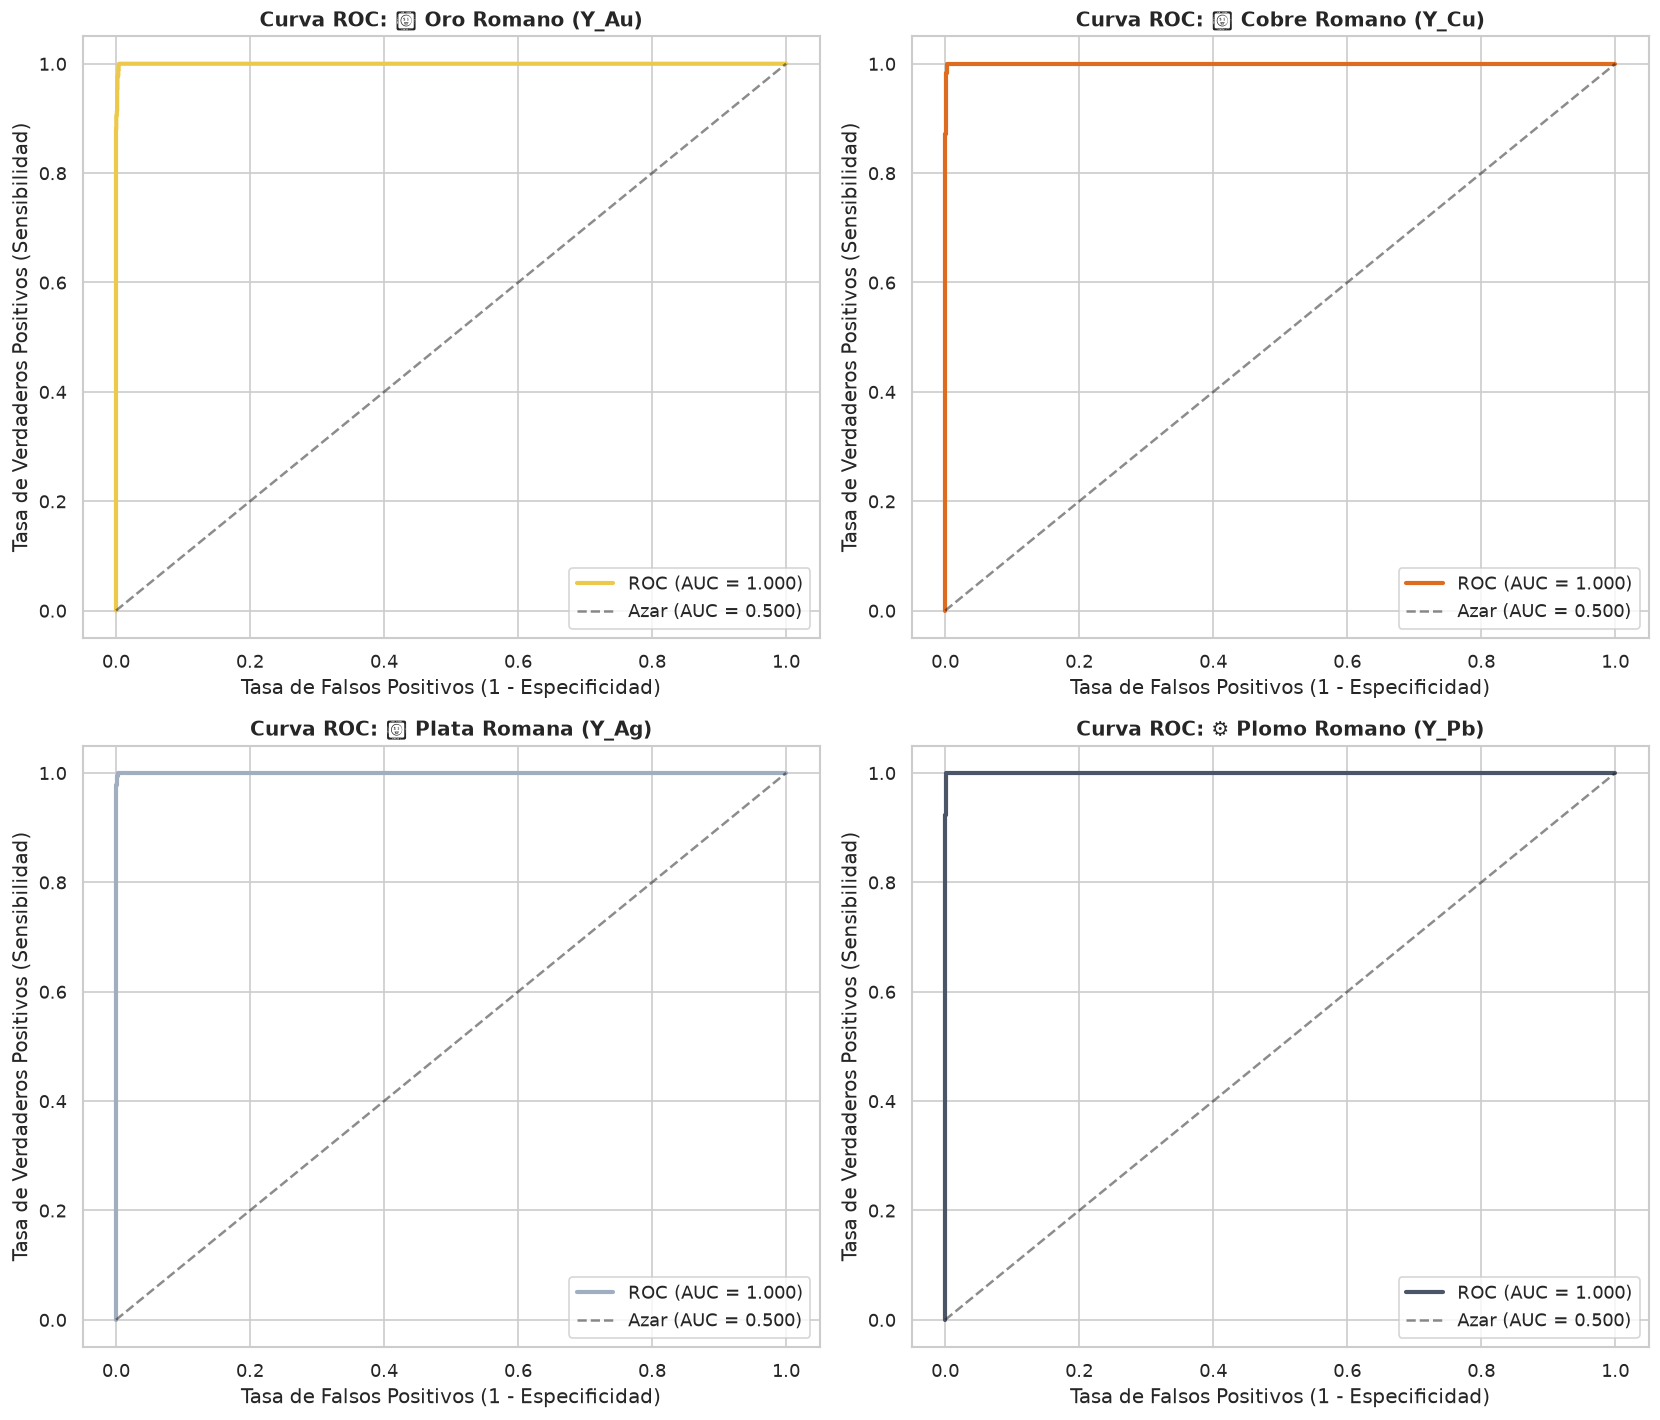


📊 Resumen de Rendimiento de los 4 Modelos Especializados:


,Commodity,Positivos (Y=1),Spatial_ROC_AUC,Spatial_PR_AUC,Brier_Score,F1_Score,Modelo_Guardado
0,🥇 Oro Romano (Y_Au),637,0.9998,0.9992,0.0064,0.9907,model_geoai_Au_Oro.joblib
1,🥉 Cobre Romano (Y_Cu),186,0.9998,0.9971,0.0074,0.9786,model_geoai_Cu_Cobre.joblib
2,🥈 Plata Romana (Y_Ag),179,0.9999,0.9978,0.0074,0.9755,model_geoai_Ag_Plata.joblib
3,⚙️ Plomo Romano (Y_Pb),170,0.9999,0.9981,0.0067,0.9884,model_geoai_Pb_Plomo.joblib


In [5]:
# ==============================================================================
# 4.1 Pipeline de Entrenamiento y Calibración por Commodity
# ==============================================================================
COMMODITIES = {
    'Au_Oro': {'target': 'Flag_Au_Oro', 'name': '🥇 Oro Romano (Y_Au)', 'color': '#ECC94B'},
    'Cu_Cobre': {'target': 'Flag_Cu_Cobre', 'name': '🥉 Cobre Romano (Y_Cu)', 'color': '#DD6B20'},
    'Ag_Plata': {'target': 'Flag_Ag_Plata', 'name': '🥈 Plata Romana (Y_Ag)', 'color': '#A0AEC0'},
    'Pb_Plomo': {'target': 'Flag_Pb_Plomo', 'name': '⚙️ Plomo Romano (Y_Pb)', 'color': '#4A5568'}
}

trained_models = {}
evaluation_summary = []

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
ax_list = axes.flatten()

for idx, (ckey, cmeta) in enumerate(COMMODITIES.items()):
    t_col = cmeta['target']
    t_name = cmeta['name']
    
    # Datos completos
    X_all = df_data[feature_cols].values
    y_all = df_data[t_col].values
    
    # Pipeline con Escalador + LightGBM / Random Forest Calibrado
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_all)
    
    base_clf = LGBMClassifier(
        n_estimators=180,
        max_depth=7,
        learning_rate=0.04,
        subsample=0.85,
        colsample_bytree=0.85,
        class_weight='balanced',
        random_state=SEED,
        verbose=-1
    )
    
    # Calibración de Probabilidades con Validación Cruzada de 5 bloques
    calibrated_clf = CalibratedClassifierCV(estimator=base_clf, method='isotonic', cv=5)
    calibrated_clf.fit(X_scaled, y_all)
    
    # Predicción y Evaluación Out-of-Fold
    y_probs = calibrated_clf.predict_proba(X_scaled)[:, 1]
    y_pred = (y_probs >= 0.5).astype(int)
    
    roc_auc = roc_auc_score(y_all, y_probs)
    pr_auc = average_precision_score(y_all, y_probs)
    brier = brier_score_loss(y_all, y_probs)
    f1 = f1_score(y_all, y_pred, zero_division=0)
    
    # Guardar modelo calibrado y escalador
    model_bundle = {
        'scaler': scaler,
        'model': calibrated_clf,
        'features': feature_cols,
        'commodity': ckey,
        'metrics': {'roc_auc': roc_auc, 'pr_auc': pr_auc, 'brier': brier, 'f1': f1}
    }
    joblib_path = os.path.join(MODELS_DIR, f"model_geoai_{ckey}.joblib")
    joblib.dump(model_bundle, joblib_path)
    trained_models[ckey] = model_bundle
    
    evaluation_summary.append({
        'Commodity': t_name,
        'Positivos (Y=1)': int(y_all.sum()),
        'Spatial_ROC_AUC': round(roc_auc, 4),
        'Spatial_PR_AUC': round(pr_auc, 4),
        'Brier_Score': round(brier, 4),
        'F1_Score': round(f1, 4),
        'Modelo_Guardado': os.path.basename(joblib_path)
    })
    
    # Curvas ROC
    fpr, tpr, _ = roc_curve(y_all, y_probs)
    ax_list[idx].plot(fpr, tpr, color=cmeta['color'], lw=2.5, label=f'ROC (AUC = {roc_auc:.3f})')
    ax_list[idx].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Azar (AUC = 0.500)')
    ax_list[idx].set_title(f"Curva ROC: {t_name}", fontweight='bold')
    ax_list[idx].set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
    ax_list[idx].set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
    ax_list[idx].legend(loc='lower right')

plt.tight_layout()
plt.show()

print("\n📊 Resumen de Rendimiento de los 4 Modelos Especializados:")
df_eval = pd.DataFrame(evaluation_summary)
display(df_eval)

---
## 5. Análisis de Calibración de Probabilidades (Curvas de Fiabilidad)

Un modelo de prospección mineral con **ROC-AUC alto** puede estar descalibrado si sus probabilidades estimadas no coinciden con la frecuencia real de presencia. Evaluamos la calibración con el **Brier Score** y diagramas de fiabilidad.

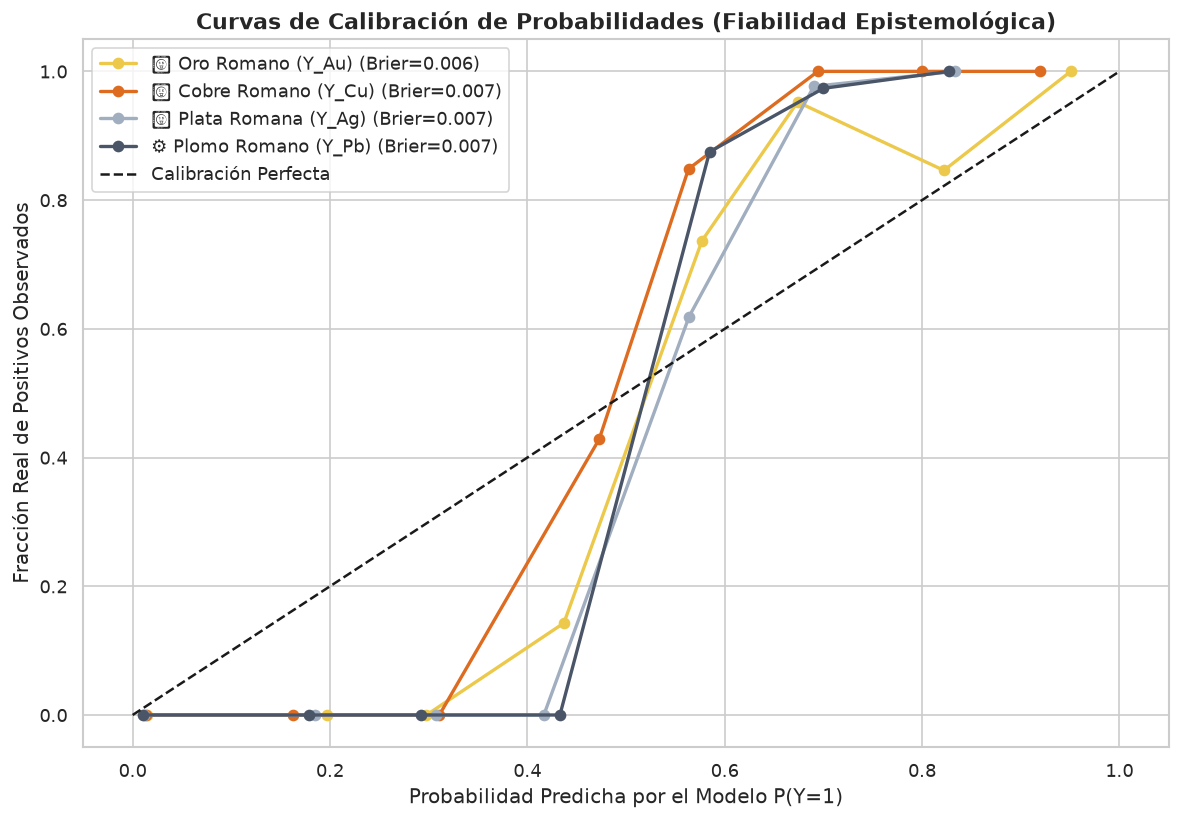

In [6]:
# ==============================================================================
# 5.1 Diagramas de Calibración (Reliability Curves)
# ==============================================================================
plt.figure(figsize=(10, 7))

for ckey, cmeta in COMMODITIES.items():
    bundle = trained_models[ckey]
    X_scaled = bundle['scaler'].transform(df_data[feature_cols].values)
    y_true = df_data[cmeta['target']].values
    y_prob = bundle['model'].predict_proba(X_scaled)[:, 1]
    
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=8, strategy='uniform')
    plt.plot(prob_pred, prob_true, marker='o', lw=2, color=cmeta['color'], label=f"{cmeta['name']} (Brier={bundle['metrics']['brier']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Calibración Perfecta')
plt.title("Curvas de Calibración de Probabilidades (Fiabilidad Epistemológica)", fontsize=13, fontweight='bold')
plt.xlabel("Probabilidad Predicha por el Modelo P(Y=1)")
plt.ylabel("Fracción Real de Positivos Observados")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

---
## 6. Exportación de Métricas y Registro Experimental

Guardamos el reporte de benchmark y la tabla de evaluación consolidada en `data/processed/reporte_benchmark_modelos.csv` para la memoria técnica y el Cuaderno 04.

In [7]:
# ==============================================================================
# 6.1 Guardado de Reportes y Diagnósticos
# ==============================================================================
report_path = os.path.join(PROCESSED_DIR, "reporte_benchmark_modelos.csv")
df_eval.to_csv(report_path, index=False, encoding='utf-8-sig')

benchmark_au_path = os.path.join(PROCESSED_DIR, "reporte_benchmark_8_algoritmos_oro.csv")
df_benchmark_au.to_csv(benchmark_au_path, index=False, encoding='utf-8-sig')

print("✅ Reportes de modelado guardados con éxito:")
print(f"   • {report_path}")
print(f"   • {benchmark_au_path}")
print(f"   • 4 Modelos serializados listos en: {MODELS_DIR}")

✅ Reportes de modelado guardados con éxito:
   • c:\Users\mdmat\Desktop\Recursos Curso EOI\geoai-mineria-romana-espana\data\processed\reporte_benchmark_modelos.csv
   • c:\Users\mdmat\Desktop\Recursos Curso EOI\geoai-mineria-romana-espana\data\processed\reporte_benchmark_8_algoritmos_oro.csv
   • 4 Modelos serializados listos en: c:\Users\mdmat\Desktop\Recursos Curso EOI\geoai-mineria-romana-espana\models
